In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import os


In [3]:

base_dir = "C:\\Users\\Vansh Sharma\\Desktop\\pneumonia detection\\chest_xray"

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# --- 2. Define Image Parameters ---
IMAGE_SIZE = (96,96)  # Resize all images to 150x150 pixels
BATCH_SIZE = 32          # Load 32 images at a time


train_datagen = ImageDataGenerator(
    rescale=1./255,      # Normalize pixel values (0-255) to be (0-1)
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)


validation_test_datagen = ImageDataGenerator(rescale=1./255)



print("Loading training data:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'  # 'binary' for 2 classes (Normal/Pneumonia)
)

print("\nLoading validation data:")
validation_generator = validation_test_datagen.flow_from_directory(
    validation_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("\nLoading test data:")
test_generator = validation_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False  # Keep test data in order for the final report
)

Loading training data:
Found 5216 images belonging to 2 classes.

Loading validation data:
Found 16 images belonging to 2 classes.

Loading test data:
Found 624 images belonging to 2 classes.


In [4]:

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)  
)

# --- 3b: Freeze the Base Model (Requirement #3) ---
# This is the "freezing" step. We tell Keras not to update
# the weights of this expert base model during training.
base_model.trainable = False
print(f"Base VGG16 model loaded. Trainable layers: {base_model.trainable}")


model = Sequential([
    # 1. The frozen base
    base_model,
    
    # 2. Flatten the 3D output of VGG16 into a 1D vector
    Flatten(),
    
    # 3. Our 1st hidden layer (Requirement #1)
    Dense(512, activation='relu'),
    
    # 4. Our dropout layer (Requirement #2)
    Dropout(0.5),  # Randomly drops 50% of neurons to prevent overfitting
    
    # 5. Our 2nd hidden layer (Requirement #1)
    Dense(256, activation='relu'),
    
    # 6. Another dropout layer
    Dropout(0.3),
    
    # 7. The Final Output Layer
    # 1 neuron = 1 output (a probability)
    # 'sigmoid' activation is perfect for binary (yes/no) classification
    Dense(1, activation='sigmoid')
])

# Print a summary of our complete model
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step
Base VGG16 model loaded. Trainable layers: False


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,206,081 (65.64 MB)

 Trainable params: 2,491,393 (9.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [5]:

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0001), 
    metrics=['accuracy']  
)

In [6]:

EPOCHS = 15

print("\nStarting model training...")

history = model.fit(
    train_generator,
    steps_per_epoch=50,
    epochs=EPOCHS,
    validation_data=validation_generator
)

print("Training finished.")
print("Keys available in the 'history' object:")
print(history.history.keys())


Starting model training...
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.7644 - loss: 0.4998 - val_accuracy: 0.8750 - val_loss: 0.4094
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.8506 - loss: 0.3414 - val_accuracy: 0.8750 - val_loss: 0.2986
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.8850 - loss: 0.2591 - val_accuracy: 0.8750 - val_loss: 0.2385
Epoch 4/15
13/50 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.8676 - loss: 0.2710

C:\Users\Vansh Sharma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 263ms/step - accuracy: 0.8822 - loss: 0.2509 - val_accuracy: 0.8750 - val_loss: 0.3192
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9013 - loss: 0.2271 - val_accuracy: 0.8750 - val_loss: 0.2663
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9256 - loss: 0.1937 - val_accuracy: 0.8750 - val_loss: 0.2292
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 49s 983ms/step - accuracy: 0.9237 - loss: 0.1972 - val_accuracy: 0.8750 - val_loss: 0.3033
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 238ms/step - accuracy: 0.8894 - loss: 0.2434 - val_accuracy: 0.8750 - val_loss: 0.2395
Epoch 9/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 49s 967ms/step - accuracy: 0.9331 - loss: 0.1796 - val_accuracy: 0.8125 - val_loss: 0.2766
Epoch 10/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 47s 937ms/step - accuracy: 0.9275 - loss: 0.1707 - val_accuracy: 0.8125 - val_loss: 0.2431
Epoch 11/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 46s 927ms/step - accuracy: 0.9362 - loss: 0.1840 - val_accuracy: 0.8125 - 

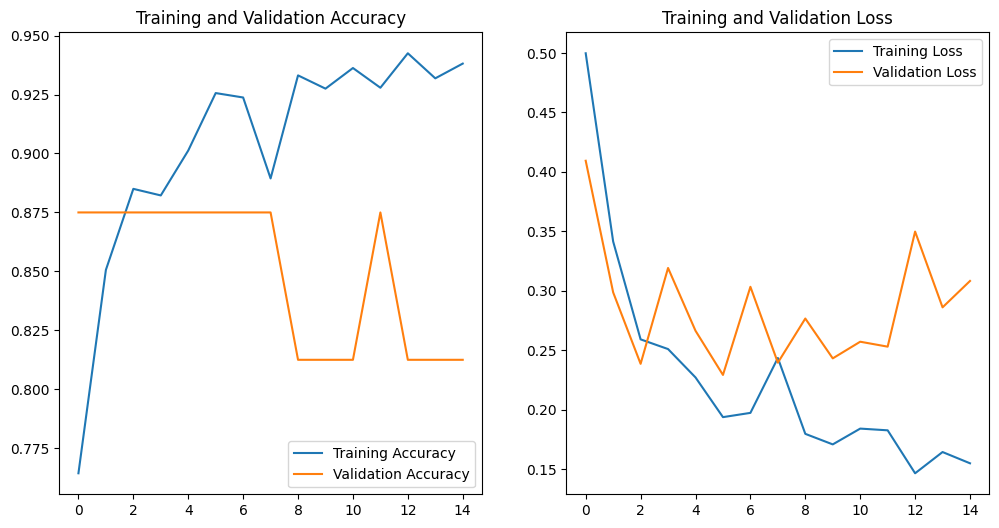


Evaluating on the test dataset...
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8910 - loss: 0.3096

Test Loss: 0.3096
Test Accuracy: 0.8910


In [7]:
# --- 6a: Plot Training History ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']


epochs_range = range(len(history.history['accuracy']))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()



print("\nEvaluating on the test dataset...")
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [8]:
model.save("chest_xray_vgg16_model.h5")